# I have trained my model on VS code editor using dgx server. I am ust using the colab to plot the outcomes.


Loaded Results Successfully
Q1(a): 128 experiments
Q1(b): 12 experiments
Q2   : 12 experiments

Q1(a) CNN Model Comparison


,dataset,model,optimizer,lr,batch_size,epochs,test_acc,train_time_ms
6,MNIST,ResNet-18,Adam,0.0001,16,10,99.55,377366.2
60,MNIST,ResNet-18,Adam,0.0010,32,14,99.52,247610.2
38,MNIST,ResNet-18,Adam,0.0001,16,14,99.51,544316.6
28,MNIST,ResNet-18,Adam,0.0010,32,10,99.49,174123.8
62,MNIST,ResNet-18,Adam,0.0001,32,14,99.49,245037.1
52,MNIST,ResNet-18,Adam,0.0010,16,14,99.49,476471.4
4,MNIST,ResNet-18,Adam,0.0010,16,10,99.48,376481.8
13,MNIST,ResNet-50,Adam,0.0010,32,10,99.47,412855.6
20,MNIST,ResNet-18,Adam,0.0010,16,10,99.46,339365.3
39,MNIST,ResNet-50,Adam,0.0001,16,14,99.46,1148224.4


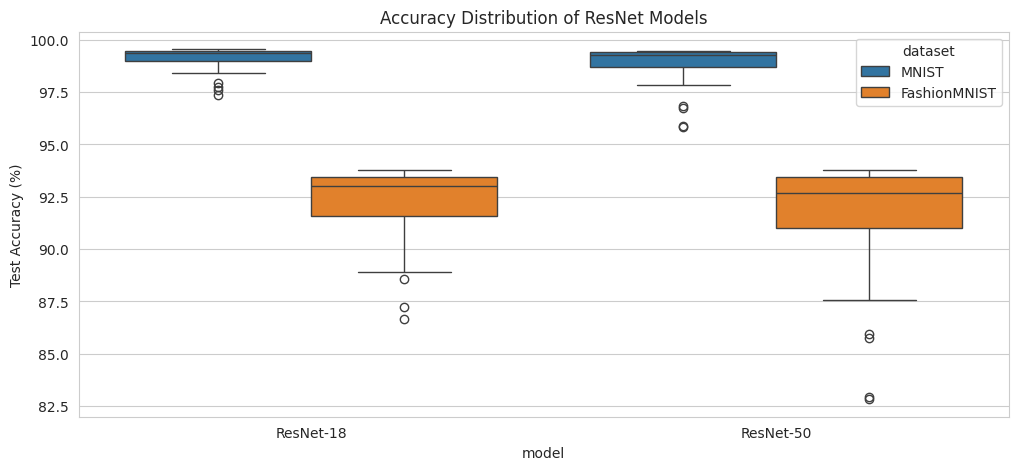

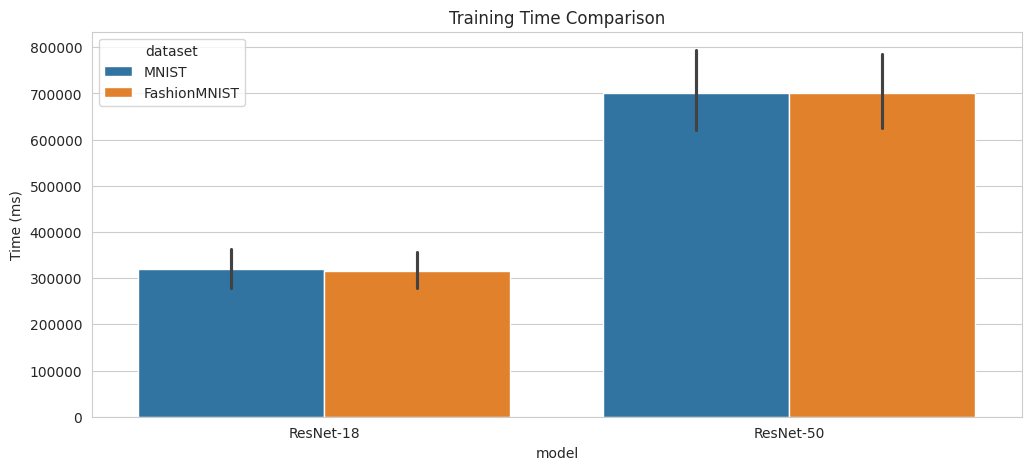

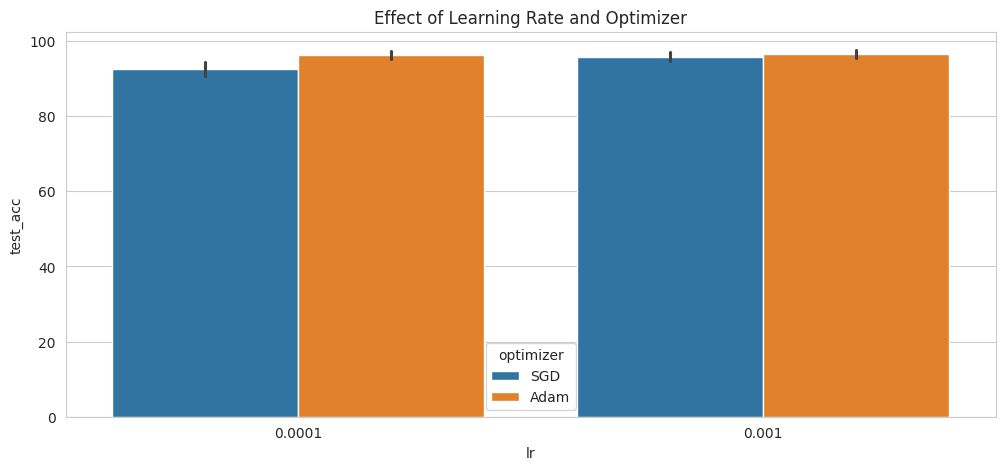


Q1(b) SVM Results


,dataset,kernel,C,degree,gamma,test_acc,train_time_ms
0,MNIST,rbf,1.0,3,scale,92.10,10756.1
1,MNIST,rbf,10.0,3,scale,93.15,10024.8
2,MNIST,rbf,0.1,3,scale,85.70,19120.0
3,MNIST,poly,1.0,2,scale,93.10,12526.9
4,MNIST,poly,1.0,3,scale,87.25,20218.6
5,MNIST,poly,10.0,3,scale,94.10,13681.5
6,FashionMNIST,rbf,1.0,3,scale,85.65,8974.5
7,FashionMNIST,rbf,10.0,3,scale,87.10,8387.4
8,FashionMNIST,rbf,0.1,3,scale,80.55,13506.7
9,FashionMNIST,poly,1.0,2,scale,85.50,9173.1


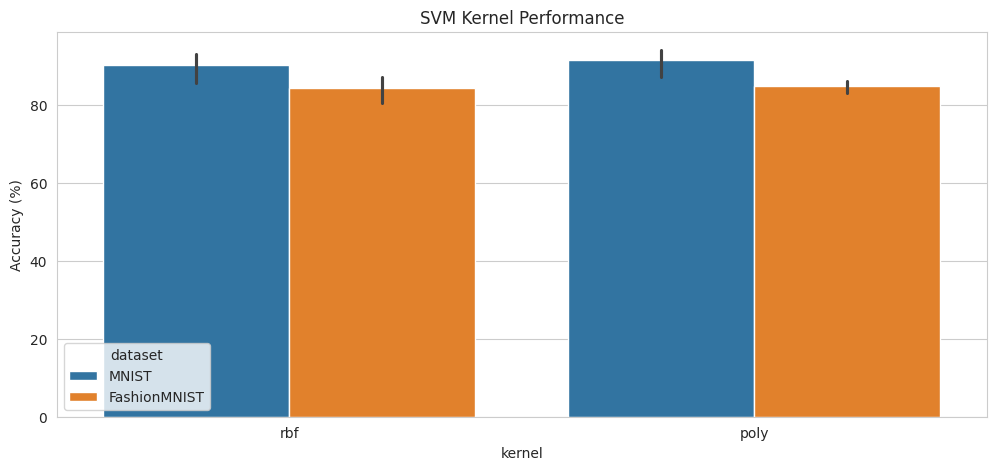

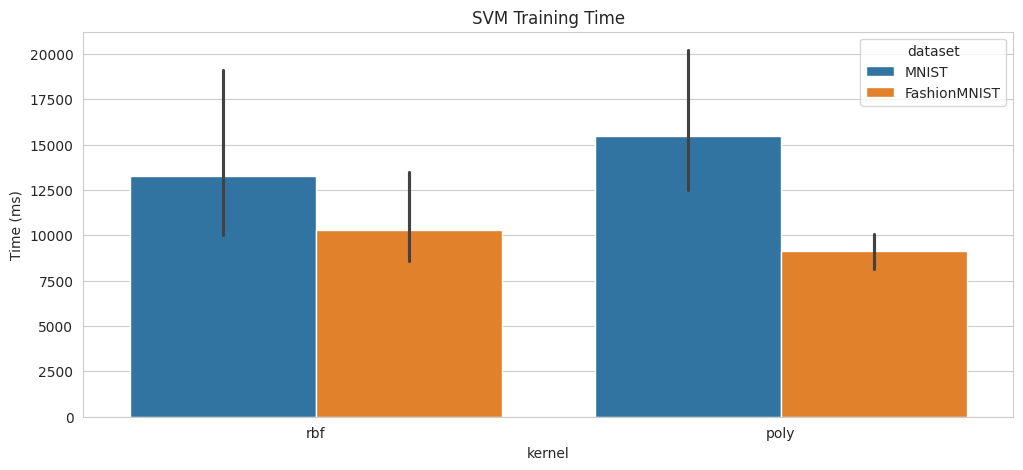


Q2 CPU vs GPU Comparison


,compute,model,batch_size,optimizer,lr,test_acc,train_time_ms,flops_g
0,CPU,ResNet-18,16,SGD,0.001,92.72,1010347.9,1.116
1,CPU,ResNet-18,16,Adam,0.001,93.51,1807036.5,1.116
2,CPU,ResNet-50,16,SGD,0.001,91.96,3376627.5,2.623
3,CPU,ResNet-50,16,Adam,0.001,93.09,4972450.0,2.623
4,CPU,ResNet-32,16,SGD,0.001,92.76,810925.2,0.141
5,CPU,ResNet-32,16,Adam,0.001,93.16,937975.5,0.141
6,GPU,ResNet-18,16,SGD,0.001,92.59,165841.7,1.116
7,GPU,ResNet-18,16,Adam,0.001,93.55,174093.3,1.116
8,GPU,ResNet-50,16,SGD,0.001,92.18,363910.9,2.623
9,GPU,ResNet-50,16,Adam,0.001,92.99,387396.9,2.623


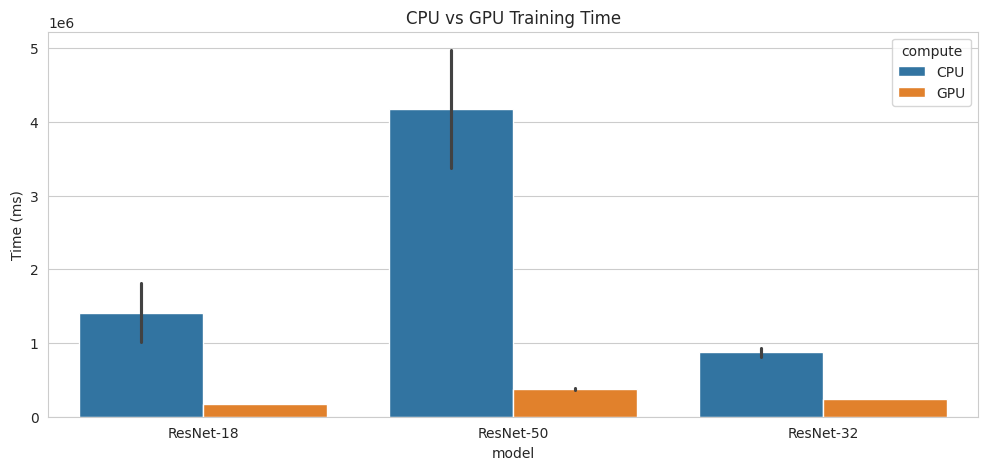

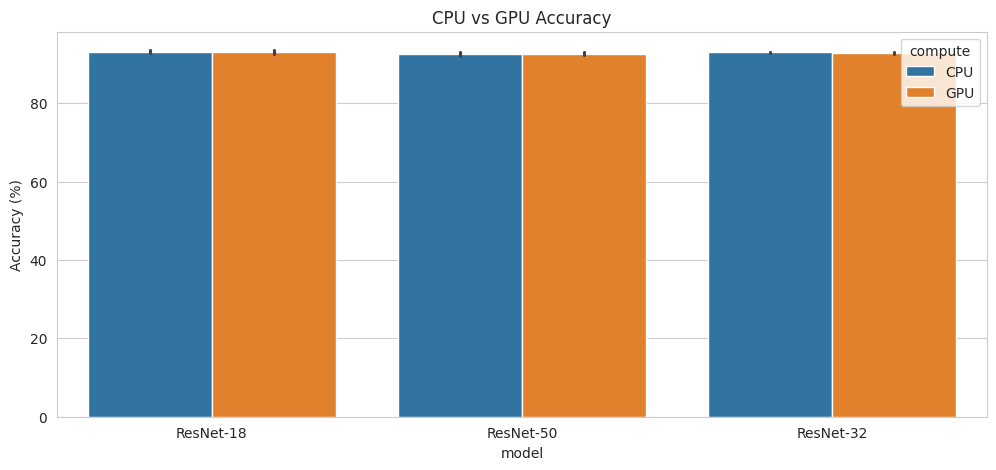


AUTO GENERATED INSIGHTS
Best CNN Model:
dataset          MNIST
model        ResNet-18
optimizer         Adam
test_acc         99.55
Name: 6, dtype: object

Best SVM Model:
dataset     MNIST
kernel       poly
C            10.0
test_acc     94.1
Name: 5, dtype: object

Fastest GPU Model:
model            ResNet-18
optimizer              SGD
train_time_ms     165841.7
Name: 6, dtype: object


In [2]:
# ==========================================
# Creates meaningful plots + summary tables
# ==========================================

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

# Load JSON file
with open('/content/all_results.json', 'r') as f:
    data = json.load(f)

# Convert to DataFrames
df_q1a = pd.DataFrame(data["q1a"])
df_q1b = pd.DataFrame(data["q1b"])
df_q2  = pd.DataFrame(data["q2"])

print("Loaded Results Successfully")
print("Q1(a):", df_q1a.shape[0], "experiments")
print("Q1(b):", df_q1b.shape[0], "experiments")
print("Q2   :", df_q2.shape[0], "experiments")

# ==================================================
# Q1(a) RESNET COMPARISON
# ==================================================
print("\n==============================")
print("Q1(a) CNN Model Comparison")
print("==============================")

best_q1a = df_q1a.sort_values("test_acc", ascending=False).head(10)
display(best_q1a[[
    "dataset","model","optimizer","lr",
    "batch_size","epochs","test_acc","train_time_ms"
]])

# Accuracy by Model
plt.figure(figsize=(12,5))
sns.boxplot(data=df_q1a, x="model", y="test_acc", hue="dataset")
plt.title("Accuracy Distribution of ResNet Models")
plt.ylabel("Test Accuracy (%)")
plt.show()

# Training Time
plt.figure(figsize=(12,5))
sns.barplot(data=df_q1a, x="model", y="train_time_ms", hue="dataset")
plt.title("Training Time Comparison")
plt.ylabel("Time (ms)")
plt.show()

# Learning Rate Effect
plt.figure(figsize=(12,5))
sns.barplot(data=df_q1a, x="lr", y="test_acc", hue="optimizer")
plt.title("Effect of Learning Rate and Optimizer")
plt.show()


# ==================================================
# Q1(b) SVM COMPARISON
# ==================================================
print("\n==============================")
print("Q1(b) SVM Results")
print("==============================")

display(df_q1b)

plt.figure(figsize=(12,5))
sns.barplot(data=df_q1b, x="kernel", y="test_acc", hue="dataset")
plt.title("SVM Kernel Performance")
plt.ylabel("Accuracy (%)")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(data=df_q1b, x="kernel", y="train_time_ms", hue="dataset")
plt.title("SVM Training Time")
plt.ylabel("Time (ms)")
plt.show()


# ==================================================
# Q2 CPU vs GPU
# ==================================================
print("\n==============================")
print("Q2 CPU vs GPU Comparison")
print("==============================")

display(df_q2)

plt.figure(figsize=(12,5))
sns.barplot(data=df_q2, x="model", y="train_time_ms", hue="compute")
plt.title("CPU vs GPU Training Time")
plt.ylabel("Time (ms)")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(data=df_q2, x="model", y="test_acc", hue="compute")
plt.title("CPU vs GPU Accuracy")
plt.ylabel("Accuracy (%)")
plt.show()


# ==================================================
# FINAL INSIGHTS
# ==================================================
print("\n==============================")
print("AUTO GENERATED INSIGHTS")
print("==============================")

best_model = df_q1a.loc[df_q1a["test_acc"].idxmax()]
print("Best CNN Model:")
print(best_model[["dataset","model","optimizer","test_acc"]])

best_svm = df_q1b.loc[df_q1b["test_acc"].idxmax()]
print("\nBest SVM Model:")
print(best_svm[["dataset","kernel","C","test_acc"]])

fastest_gpu = df_q2[df_q2["compute"]=="GPU"].sort_values("train_time_ms").iloc[0]
print("\nFastest GPU Model:")
print(fastest_gpu[["model","optimizer","train_time_ms"]])

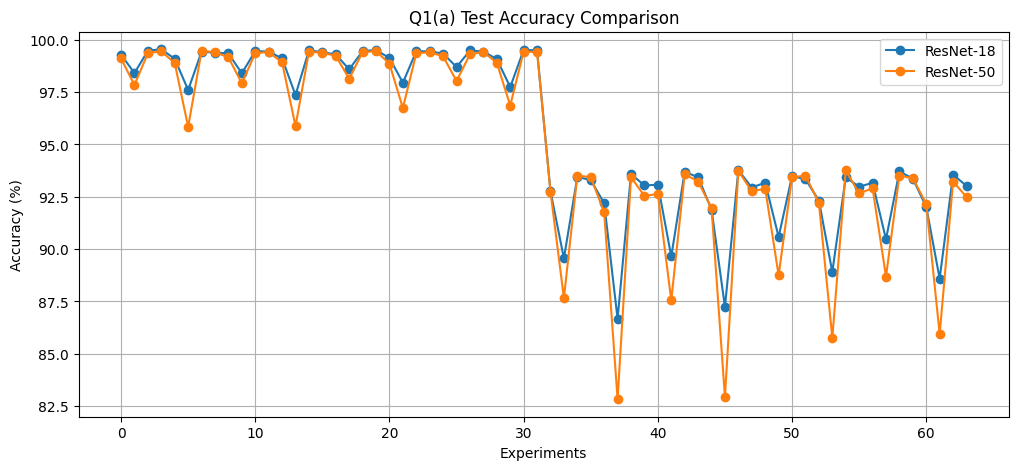

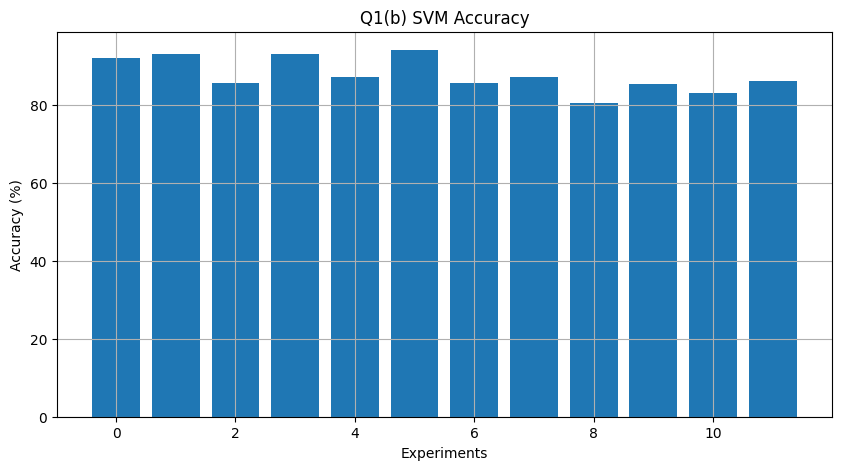

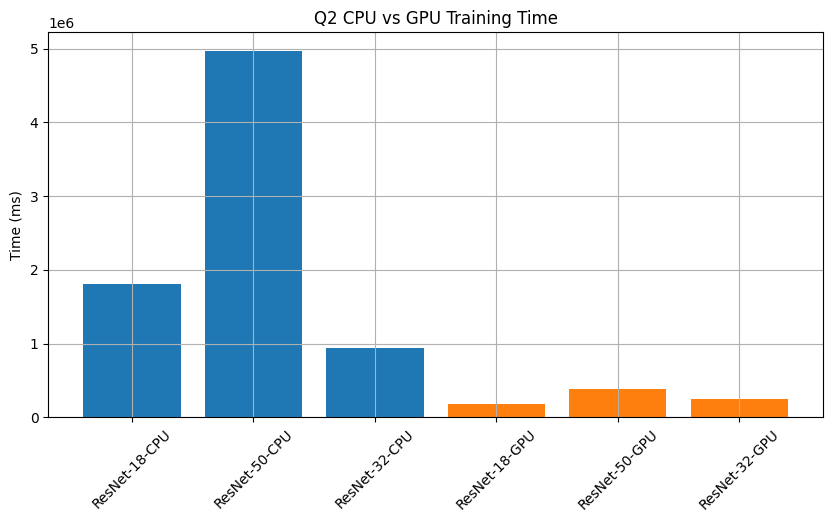

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open('/content/all_results.json', 'r') as f:
    data = json.load(f)

# Q1(a)
df_q1a = pd.DataFrame(data['q1a'])
plt.figure(figsize=(12,5))
for model in df_q1a['model'].unique():
    subset = df_q1a[df_q1a['model'] == model]
    plt.plot(range(len(subset)), subset['test_acc'], marker='o', label=model)
plt.title("Q1(a) Test Accuracy Comparison")
plt.xlabel("Experiments")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

# Q1(b)
df_q1b = pd.DataFrame(data['q1b'])
plt.figure(figsize=(10,5))
plt.bar(range(len(df_q1b)), df_q1b['test_acc'])
plt.title("Q1(b) SVM Accuracy")
plt.xlabel("Experiments")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

# Q2
df_q2 = pd.DataFrame(data['q2'])
plt.figure(figsize=(10,5))
for compute in df_q2['compute'].unique():
    subset = df_q2[df_q2['compute']==compute]
    plt.bar(subset['model'] + "-" + compute, subset['train_time_ms'])
plt.title("Q2 CPU vs GPU Training Time")
plt.ylabel("Time (ms)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [ ]:
"""
=============================================================
  DLOps Lab Assignment 1 — Complete Pipeline
  Covers: Q1(a), Q1(b), Q2
  Framework : PyTorch + Scikit-learn
  Author    : Kushal Sharma (M25CSA016)
=============================================================

HOW TO RUN (VS Code / terminal):
  python DLOps_Assignment1.py

Results are saved to ./results/ folder automatically.
"""

# ──────────────────────────────────────────────────────────────
# SECTION 0 — Install dependencies (run once in terminal)
# pip install torch torchvision scikit-learn thop matplotlib pandas tabulate
# ──────────────────────────────────────────────────────────────

import os, time, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")          # headless — saves PNGs instead of showing plots
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Subset, random_split

import torchvision
import torchvision.transforms as T
import torchvision.models as models

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

from thop import profile as thop_profile       # pip install thop
from tabulate import tabulate                   # pip install tabulate

# ──────────────────────────────────────────────────────────────
# SECTION 1 — Global Settings
# ──────────────────────────────────────────────────────────────

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

NUM_CLASSES  = 10
IMG_SIZE     = 32        # resize MNIST/FashionMNIST to 32×32 for ResNet
USE_AMP      = True      # constant per assignment spec

# ──────────────────────────────────────────────────────────────
# SECTION 2 — Data Loading  (70 % train | 10 % val | 20 % test)
# ──────────────────────────────────────────────────────────────

def get_transforms(img_size=32):
    """Convert grayscale → 3-channel RGB and resize for ResNet."""
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.Grayscale(num_output_channels=3),   # 1-ch → 3-ch
        T.ToTensor(),
        T.Normalize(mean=[0.5, 0.5, 0.5],
                    std=[0.5, 0.5, 0.5]),
    ])

def get_datasets(dataset_name: str, img_size: int = 32):
    """
    Downloads and returns train/val/test DataSet objects.
    Split: 70 % train | 10 % val | 20 % test  (from the official train set)
    The official test set is used as-is for the final 20 % test.
    """
    tfm = get_transforms(img_size)

    DS = torchvision.datasets.MNIST if dataset_name == "MNIST" \
         else torchvision.datasets.FashionMNIST

    full_train = DS(root="./data", train=True,  download=True, transform=tfm)
    test_set   = DS(root="./data", train=False, download=True, transform=tfm)

    # Official split: 60k train → 42k train + 6k val + keep 12k for extra
    # Assignment says 70-10-20 of total data:
    # Total = 60k + 10k = 70k → 49k train | 7k val | 14k test
    n_total = len(full_train) + len(test_set)   # 70 000
    n_train = int(0.70 * n_total)               # 49 000
    n_val   = int(0.10 * n_total)               # 7 000
    n_test  = n_total - n_train - n_val         # 14 000

    from torch.utils.data import ConcatDataset
    all_data = ConcatDataset([full_train, test_set])

    # Reproducible split
    gen = torch.Generator().manual_seed(SEED)
    train_set, val_set, test_set_split = random_split(
        all_data, [n_train, n_val, n_test], generator=gen)

    return train_set, val_set, test_set_split


def get_loaders(dataset_name, batch_size, pin_memory=True, num_workers=4):
    train_set, val_set, test_set = get_datasets(dataset_name)
    train_loader = DataLoader(train_set, batch_size=batch_size,
                              shuffle=True,  pin_memory=pin_memory,
                              num_workers=num_workers)
    val_loader   = DataLoader(val_set,   batch_size=256,
                              shuffle=False, pin_memory=pin_memory,
                              num_workers=num_workers)
    test_loader  = DataLoader(test_set,  batch_size=256,
                              shuffle=False, pin_memory=pin_memory,
                              num_workers=num_workers)
    return train_loader, val_loader, test_loader


# ──────────────────────────────────────────────────────────────
# SECTION 3 — Model Builder
# ──────────────────────────────────────────────────────────────

def build_model(model_name: str, num_classes: int = 10):
    """
    Returns a ResNet model with the final FC layer replaced for num_classes.
    First conv layer adjusted for small 32×32 inputs.
    pretrained = False  (assignment requirement).
    """
    if model_name == "ResNet-18":
        model = models.resnet18(weights=None)
    elif model_name == "ResNet-50":
        model = models.resnet50(weights=None)
    elif model_name == "ResNet-32":
        # ResNet-32 is a CIFAR-style model not in torchvision.
        # We approximate it with a custom small ResNet.
        model = _build_resnet32(num_classes)
        return model
    else:
        raise ValueError(f"Unknown model: {model_name}")

    # Adapt first conv for 32×32 images (remove large stride & max-pool)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()

    # Replace final FC
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


# ---- Minimal ResNet-32 for CIFAR-style (Optional Q2) ----
class _BasicBlock32(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.skip  = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch))

    def forward(self, x):
        return self.relu(self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))) + self.skip(x))

def _build_resnet32(num_classes=10):
    layers = []
    layers.append(nn.Conv2d(3, 16, 3, 1, 1, bias=False))
    layers.append(nn.BatchNorm2d(16))
    layers.append(nn.ReLU(inplace=True))
    cfg = [(16,16,5,1),(16,32,5,2),(32,64,5,2)]
    for in_ch, out_ch, n, stride in cfg:
        for i in range(n):
            layers.append(_BasicBlock32(in_ch if i==0 else out_ch,
                                        out_ch,
                                        stride if i==0 else 1))
    layers.append(nn.AdaptiveAvgPool2d(1))
    layers.append(nn.Flatten())
    layers.append(nn.Linear(64, num_classes))
    return nn.Sequential(*layers)


# ──────────────────────────────────────────────────────────────
# SECTION 4 — FLOPs Calculator
# ──────────────────────────────────────────────────────────────

def compute_flops(model, device, img_size=32, channels=3):
    """Returns FLOPs (Giga) using thop."""
    dummy = torch.randn(1, channels, img_size, img_size).to(device)
    model_cpu = model.cpu()
    dummy_cpu = dummy.cpu()
    try:
        macs, _ = thop_profile(model_cpu, inputs=(dummy_cpu,), verbose=False)
        flops_g = macs * 2 / 1e9      # MACs → FLOPs, convert to G
    except Exception:
        flops_g = float("nan")
    model.to(device)
    return round(flops_g, 3)


# ──────────────────────────────────────────────────────────────
# SECTION 5 — Training & Evaluation Functions
# ──────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast(enabled=USE_AMP):
            outputs = model(images)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += images.size(0)
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        with autocast(enabled=USE_AMP):
            outputs = model(images)
            loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += images.size(0)
    return total_loss / total, 100.0 * correct / total


def train_model(model_name, dataset_name, optimizer_name, lr, batch_size,
                num_epochs, pin_memory, device, verbose=True):
    """
    Full train → val → test pipeline.
    Returns a result dict with accuracy, train_time_ms, history, flops.
    """
    # ----- Loaders -----
    train_loader, val_loader, test_loader = get_loaders(
        dataset_name, batch_size, pin_memory=pin_memory)

    # ----- Model -----
    model     = build_model(model_name, NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    scaler    = GradScaler(enabled=USE_AMP)

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    flops = compute_flops(model, device)

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}

    start_wall = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion,
                                          optimizer, scaler, device)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        if verbose:
            print(f"  [{epoch:02d}/{num_epochs}]  "
                  f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2f}%  |  "
                  f"Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.2f}%")

    train_time_ms = (time.perf_counter() - start_wall) * 1000.0

    _, test_acc = evaluate(model, test_loader, criterion, device)

    print(f"\n  ✔ Test Accuracy: {test_acc:.2f}%  |  "
          f"Train Time: {train_time_ms/1000:.1f}s  |  FLOPs: {flops}G\n")

    return {
        "model":         model_name,
        "dataset":       dataset_name,
        "optimizer":     optimizer_name,
        "lr":            lr,
        "batch_size":    batch_size,
        "epochs":        num_epochs,
        "pin_memory":    pin_memory,
        "device":        str(device),
        "test_acc":      round(test_acc, 2),
        "train_time_ms": round(train_time_ms, 1),
        "flops_g":       flops,
        "history":       history,
        "model_obj":     model,
    }


# ──────────────────────────────────────────────────────────────
# SECTION 6 — Plotting Helper
# ──────────────────────────────────────────────────────────────

def plot_history(history, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"],   label="Val")
    axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(True)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.close()
    print(f"  Plot saved → {save_path}")


# ──────────────────────────────────────────────────────────────
# SECTION 7 — Q1(a): ResNet-18 & ResNet-50 on MNIST + FashionMNIST
# ──────────────────────────────────────────────────────────────

print("\n" + "="*65)
print("  Q1(a): ResNet Experiments on MNIST & FashionMNIST")
print("="*65)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n  Using device: {DEVICE}\n")

# Required experiments (all with USE_AMP=True)
Q1A_GRID = [
    # (batch_size, optimizer, lr)
    (16, "SGD",  0.001),
    (16, "SGD",  0.0001),
    (16, "Adam", 0.001),
    (16, "Adam", 0.0001),
    (32, "SGD",  0.001),
    (32, "SGD",  0.0001),   # [Optional] — keep for completeness
    (32, "Adam", 0.001),    # [Optional] — keep for completeness
    (32, "Adam", 0.0001),
]

# Two epoch settings (assignment asks for at least two)
EPOCH_SETTINGS = [10, 20]

# Two pin_memory settings
PIN_MEMORY_SETTINGS = [False, True]

q1a_results = []

for dataset_name in ["MNIST", "FashionMNIST"]:
    print(f"\n{'─'*50}")
    print(f"  Dataset: {dataset_name}")
    print(f"{'─'*50}")

    for num_epochs in EPOCH_SETTINGS:
        for pin_memory in PIN_MEMORY_SETTINGS:
            for bs, opt, lr in Q1A_GRID:
                for model_name in ["ResNet-18", "ResNet-50"]:

                    tag = (f"{dataset_name}_{model_name}_BS{bs}_{opt}"
                           f"_LR{lr}_E{num_epochs}_PM{pin_memory}")
                    print(f"\n▶  {tag}")

                    result = train_model(
                        model_name   = model_name,
                        dataset_name = dataset_name,
                        optimizer_name = opt,
                        lr           = lr,
                        batch_size   = bs,
                        num_epochs   = num_epochs,
                        pin_memory   = pin_memory,
                        device       = DEVICE,
                        verbose      = True,
                    )

                    # Save train-val graph
                    plot_path = os.path.join(
                        RESULTS_DIR,
                        f"{tag}_history.png")
                    plot_history(result["history"], tag, plot_path)

                    # Save best model (only if accuracy > 80 %)
                    if result["test_acc"] > 80.0:
                        model_path = os.path.join(
                            RESULTS_DIR, f"{tag}_model.pth")
                        torch.save(result["model_obj"].state_dict(), model_path)
                        print(f"  Model saved → {model_path}")

                    # Drop heavy objects before storing
                    result.pop("model_obj")
                    result.pop("history")
                    q1a_results.append(result)

# Save Q1(a) results table
df_q1a = pd.DataFrame(q1a_results).drop(columns=["history"], errors="ignore")
df_q1a.to_csv(os.path.join(RESULTS_DIR, "q1a_results.csv"), index=False)
print("\n\n  Q1(a) Summary Table:")
print(tabulate(df_q1a[["dataset","model","batch_size","optimizer",
                         "lr","epochs","pin_memory","test_acc"]],
               headers="keys", tablefmt="grid", showindex=False))


# ──────────────────────────────────────────────────────────────
# SECTION 8 — Q1(b): SVM Classifier on MNIST & FashionMNIST
# ──────────────────────────────────────────────────────────────

print("\n" + "="*65)
print("  Q1(b): SVM Classifier")
print("="*65)

def get_flat_data(dataset_name, max_train=10000, max_test=2000):
    """
    Loads raw pixel data (flattened) for SVM.
    We cap samples to keep SVM training tractable.
    """
    tfm = T.Compose([T.ToTensor()])
    DS  = torchvision.datasets.MNIST if dataset_name == "MNIST" \
          else torchvision.datasets.FashionMNIST

    train_ds = DS(root="./data", train=True,  download=True, transform=tfm)
    test_ds  = DS(root="./data", train=False, download=True, transform=tfm)

    # Sub-sample for speed
    train_ds = Subset(train_ds, list(range(min(max_train, len(train_ds)))))
    test_ds  = Subset(test_ds,  list(range(min(max_test,  len(test_ds)))))

    def to_numpy(ds):
        loader = DataLoader(ds, batch_size=512, shuffle=False)
        Xs, Ys = [], []
        for imgs, lbs in loader:
            Xs.append(imgs.view(imgs.size(0), -1).numpy())
            Ys.append(lbs.numpy())
        return np.concatenate(Xs), np.concatenate(Ys)

    X_tr, y_tr = to_numpy(train_ds)
    X_te, y_te = to_numpy(test_ds)
    return X_tr, y_tr, X_te, y_te


SVM_CONFIGS = [
    # (kernel, C, degree, gamma)
    ("rbf",  1.0,  3, "scale"),
    ("rbf",  10.0, 3, "scale"),
    ("rbf",  0.1,  3, "scale"),
    ("poly", 1.0,  2, "scale"),
    ("poly", 1.0,  3, "scale"),
    ("poly", 10.0, 3, "scale"),
]

q1b_results = []

for dataset_name in ["MNIST", "FashionMNIST"]:
    print(f"\n{'─'*50}")
    print(f"  Dataset: {dataset_name}")
    print(f"{'─'*50}")

    X_tr, y_tr, X_te, y_te = get_flat_data(dataset_name)

    # Normalize features
    scaler_sk = StandardScaler()
    X_tr_s = scaler_sk.fit_transform(X_tr)
    X_te_s = scaler_sk.transform(X_te)

    for kernel, C, degree, gamma in SVM_CONFIGS:
        tag = f"SVM_{dataset_name}_{kernel}_C{C}_deg{degree}"
        print(f"\n▶  {tag}")

        clf = SVC(kernel=kernel, C=C, degree=degree,
                  gamma=gamma, random_state=SEED)

        t0 = time.perf_counter()
        clf.fit(X_tr_s, y_tr)
        train_time_ms = (time.perf_counter() - t0) * 1000.0

        y_pred   = clf.predict(X_te_s)
        test_acc = accuracy_score(y_te, y_pred) * 100.0

        print(f"  Test Acc: {test_acc:.2f}%  |  Train Time: {train_time_ms:.1f} ms")

        q1b_results.append({
            "dataset":       dataset_name,
            "kernel":        kernel,
            "C":             C,
            "degree":        degree,
            "gamma":         gamma,
            "test_acc":      round(test_acc, 2),
            "train_time_ms": round(train_time_ms, 1),
        })

df_q1b = pd.DataFrame(q1b_results)
df_q1b.to_csv(os.path.join(RESULTS_DIR, "q1b_results.csv"), index=False)
print("\n\n  Q1(b) Summary Table:")
print(tabulate(df_q1b, headers="keys", tablefmt="grid", showindex=False))


# ──────────────────────────────────────────────────────────────
# SECTION 9 — Q2: CPU vs GPU Comparison on FashionMNIST
# ──────────────────────────────────────────────────────────────

print("\n" + "="*65)
print("  Q2: CPU vs GPU Comparison — FashionMNIST")
print("="*65)

Q2_CONFIGS = [
    # (model_name, batch_size, optimizer, lr)
    ("ResNet-18", 16, "SGD",  0.001),
    ("ResNet-18", 16, "Adam", 0.001),
    ("ResNet-50", 16, "SGD",  0.001),
    ("ResNet-50", 16, "Adam", 0.001),
    # Optional ResNet-32:
    ("ResNet-32", 16, "SGD",  0.001),
    ("ResNet-32", 16, "Adam", 0.001),
]

Q2_EPOCHS = 5   # fewer epochs for CPU (training full 20 on CPU is very slow)

q2_results = []
devices_to_test = [torch.device("cpu")]
if torch.cuda.is_available():
    devices_to_test.append(torch.device("cuda"))
else:
    print("\n  ⚠  No GPU detected — Q2 GPU rows will be skipped.\n")

for compute_device in devices_to_test:
    compute_label = "GPU" if compute_device.type == "cuda" else "CPU"
    print(f"\n{'─'*50}")
    print(f"  Compute: {compute_label}  ({compute_device})")
    print(f"{'─'*50}")

    for model_name, bs, opt, lr in Q2_CONFIGS:
        tag = f"Q2_{compute_label}_{model_name}_BS{bs}_{opt}_LR{lr}"
        print(f"\n▶  {tag}")

        result = train_model(
            model_name     = model_name,
            dataset_name   = "FashionMNIST",
            optimizer_name = opt,
            lr             = lr,
            batch_size     = bs,
            num_epochs     = Q2_EPOCHS,
            pin_memory     = (compute_device.type == "cuda"),
            device         = compute_device,
            verbose        = True,
        )

        plot_path = os.path.join(RESULTS_DIR, f"{tag}_history.png")
        plot_history(result["history"], tag, plot_path)

        result.pop("model_obj")
        result.pop("history")

        q2_results.append({
            "compute":       compute_label,
            "model":         model_name,
            "batch_size":    bs,
            "optimizer":     opt,
            "lr":            lr,
            "test_acc":      result["test_acc"],
            "train_time_ms": result["train_time_ms"],
            "flops_g":       result["flops_g"],
        })

df_q2 = pd.DataFrame(q2_results)
df_q2.to_csv(os.path.join(RESULTS_DIR, "q2_results.csv"), index=False)
print("\n\n  Q2 Summary Table:")
print(tabulate(df_q2, headers="keys", tablefmt="grid", showindex=False))


# ──────────────────────────────────────────────────────────────
# SECTION 10 — Save all results to one JSON for easy reference
# ──────────────────────────────────────────────────────────────

all_results = {
    "q1a": q1a_results,
    "q1b": q1b_results,
    "q2":  q2_results,
}
with open(os.path.join(RESULTS_DIR, "all_results.json"), "w") as f:
    json.dump(all_results, f, indent=2)

print("\n\n" + "="*65)
print("  ✅  All experiments complete!")
print(f"  Results folder: {os.path.abspath(RESULTS_DIR)}")
print("="*65)
